In [1]:
from langgraph.graph import START, END, StateGraph

from typing import TypedDict

In [26]:
class MyState(TypedDict):
    a: int
    b: int
    c: int

In [27]:
def Node1_func(state: MyState):
    state['a'] = 10
    state['b'] = 20
    return state

In [28]:
def Node2_func(state: MyState):
    state['c'] = state['a'] + state['b']
    return state

In [29]:
graph = StateGraph(MyState)
graph.add_node("Node1", Node1_func)
graph.add_node("Node2", Node2_func)

graph.add_edge(START, "Node1")
graph.add_edge("Node1", "Node2")
graph.add_edge("Node2", END)

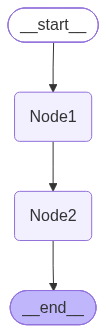

In [30]:
workflow_state = graph.compile()
workflow_state

In [25]:
result = workflow_state.invoke({'a': 0, 'b': 0, 'c': 0})

print(result)  # Output: {'a': 10, 'b': 20, 'c': 30}

{'a': 10, 'b': 20, 'c': 30}
